<a href="https://colab.research.google.com/github/rajkgoel/AW-Internet-Sales1/blob/master/Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clustering


Clustering falls in the category of unsupervised learning.
In supervised learning:
- You have X → Y
- You know the correct answer.

In unsupervised learning:
- You only have X
- There is no Y (no labels).

You’re asking the algorithm:

“Find hidden structure in this data.”

📌 Example

Supervised:
- Email → Spam / Not Spam
- House features → Price

Unsupervised:
- Group customers by behavior
- Detect unusual transactions
- Discover natural patterns

Unsupervised learning tries to:
- Find groups (Clustering)
- Reduce dimensions (PCA)
- Find associations (Market basket analysis)

You are discovering patterns, not predicting labels.

In classification:
You already know the categories.

Example:
Dog vs Cat → You train model to recognize them.

In clustering:
You don’t know categories beforehand.
The model creates them.

Example:
Given 10,000 customers, the algorithm might discover:
- Budget buyers
- Luxury buyers
- Seasonal shoppers

You didn’t tell it those categories.

# Distance Metrics

Distance is EVERYTHING in clustering.

Clustering = grouping based on similarity.

Similarity = measured by distance.

**Euclidean Distance**

📌 Formula

Between two points:
$$ d= \sqrt{∑(xi​−yi​)^2} $$

🧠 Intuition

Straight-line distance.

Works best when:
- Clusters are spherical
- Features are continuous
- Data is scaled

📉 Sensitive to:
- Outliers
- Large scale differences

Used in:
- K-Means

---
**🔹 Manhattan Distance**

📌 Formula
$$ d=∑∣xi​−yi​∣  $$
🧠 Intuition

City block distance (like roads in Manhattan).

Works better when:
- Data has high dimensions
- You want robustness to outliers

Used in:
- K-Medians
- Some KNN variations

---
**Cosine Similarity**

📌 Formula
$$ cos(θ)=A⋅B​ / (∣∣A∣∣∣∣B∣∣) $$

🧠 Intuition

Measures angle between vectors, not magnitude.

Very useful when:
- Direction matters more than magnitude
- Text data (TF-IDF vectors)

Example:
Two long documents may have different lengths but similar topics → cosine captures that.

Used in:
- Document clustering
- NLP

🎯 When to Choose What?

| Scenario |	Best Metric |
| --- | --- |
| Numeric features, compact clusters |	Euclidean |
| High dimensional sparse data |	Cosine |
| Robust to outliers	| Manhattan |

# K-Means


K-Means minimizes:

Within Cluster Sum of Squares (WCSS)
📌 Mathematical Definition
$$WCSS = \sum_{k=1}^{K} \sum_{x \in C_k} ||x - \mu_k||^2$$

Where:
- K = number of clusters
- $ C_k = cluster k $
- $ μ_k = centroid of cluster k $

🧠 What It Means

For every cluster:
- Compute distance of each point from its centroid
- Square it
- Sum it

Then sum across all clusters.

We want this total to be as small as possible.

🎯 Why Squared?
1. Penalizes far points more
2. Makes math differentiable
3. Leads to mean being optimal centroid

That’s why centroid = average.

🧠 **Geometric Interpretation of Clusters**

Each cluster forms something like a “ball” in space.

WCSS measures:

How compact that ball is.

- Small WCSS → tight cluster
- Large WCSS → spread cluster


📊 What Happens When K Changes?
Case 1: Small K

Few clusters → large spread → long lines
High WCSS

Case 2: Large K

More clusters → each cluster smaller
- Shorter lines
- Lower WCSS

If K = number of points:

Every point is its own cluster
- Distance = 0
- WCSS = 0

But that’s useless.

This is why we use the Elbow Method.

---

📌 **Intuition Summary**

WCSS is:

The total squared “stretch” inside clusters.

K-Means tries to:

Make each cluster as compact as possible.

🎯 Important Conceptual Realization

Because it minimizes squared Euclidean distance:
- Clusters tend to be spherical.
- It struggles with elongated shapes.
- It struggles with uneven density.

Example of failure:
- Two moon-shaped clusters → K-Means fails.
- K-Means is sensitive to outliers.

Cluster Labels: [0 0 0 1 1 1 1 1]
Centroids:
 [[2.56666667e+01 3.10000000e+04]
 [3.80000000e+01 7.67800000e+04]]


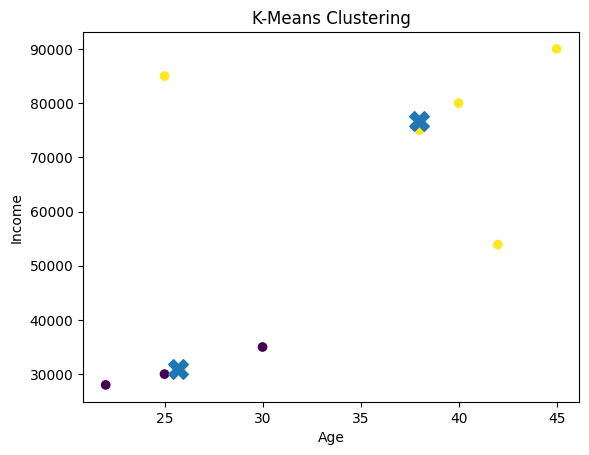

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1️⃣ Create dataset (Age, Income)
X = np.array([
    [25, 30000],
    [30, 35000],
    [22, 28000],
    [25, 85000],
    [40, 80000],
    [45, 90000],
    [42, 53900],
    [38, 75000]
])

# 2️⃣ Apply KMeans
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X)

# 3️⃣ Get cluster labels
labels = kmeans.labels_

# 4️⃣ Get centroids
centroids = kmeans.cluster_centers_

print("Cluster Labels:", labels)
print("Centroids:\n", centroids)

# 5️⃣ Plot clusters
plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200)
plt.xlabel("Age")
plt.ylabel("Income")
plt.title("K-Means Clustering")
plt.show()

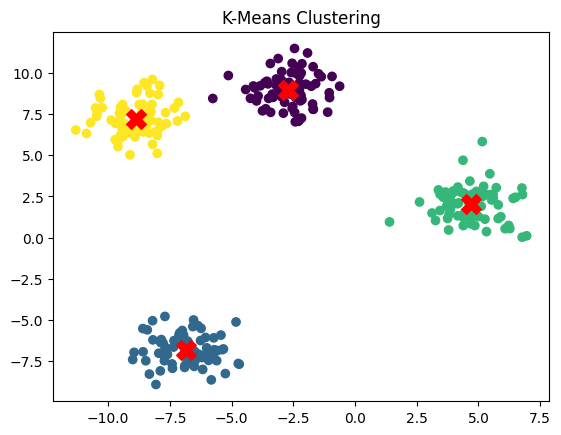

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# Create a synthetic dataset
X, _ = make_blobs(n_samples=300, centers=4, random_state=42)

# Run K-Means
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X)

# Extract cluster labels and centroids
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

# Plot
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200, c='red')
plt.title("K-Means Clustering")
plt.show()

# WCSS vs Iteration

Notice the curve:
- Iteration 1 → very high WCSS
- Iteration 2 → massive drop
- Iteration 3 → small improvement

🔥 Important Concept

WCSS always:
- Decreases each iteration
- Converges to local minimum
- Never increases

This is why K-Means is guaranteed to converge.

# Elbow Method & Silhouette

How do we choose K?
This is where Elbow Method and Silhouette Score come in.

🎯 Why Choosing K Matters
- If K too small → clusters are too broad → high WCSS
- If K too large → over-segmentation → meaningless micro-clusters
- If K = number of points → WCSS = 0 (useless)

So we need a systematic way to choose K.



Elbow Method
---
As K increases:
- WCSS always decreases
- But improvement slows down

We look for a point where improvement sharply slows.

That bend is called the “Elbow.”

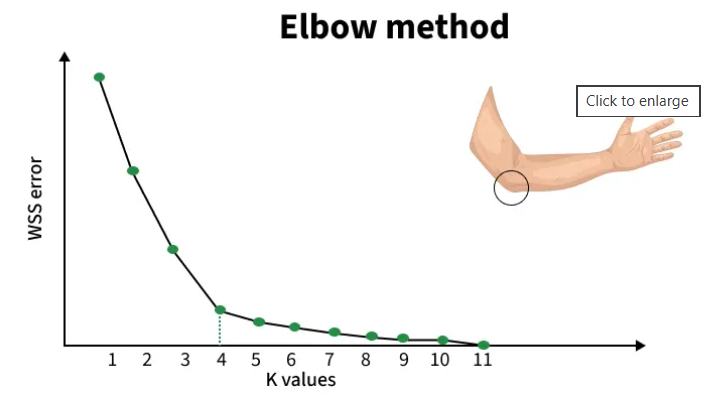

📊 What We Plot

For K = 1 to 10:
- Run K-Means
- Compute WCSS
- Plot:

$$ K  vs  WCSS $$

🧠 **Why It Works (Geometric Intuition)**

When K is small:
- Each cluster covers large area
- Large distances
- High WCSS

When K increases:
- Clusters become tighter
- WCSS drops quickly

After a point:
- Adding clusters gives only small improvement
- Diminishing returns

That bend = optimal K.

Elbow is:
- Sometimes unclear
- Sometimes smooth curve
- Subjective

Not always reliable.

Silhouette Score
---

This measures:

How well-separated clusters are.

🟢 For Each Point:

Compute:

a = Average distance to points in same cluster
b = Average distance to points in nearest other cluster

Then:

$$ S = (b -a) / max(a,b) $$​

| Score | Meaning             |
| ----- | ------------------- |
| ≈ 1   | Very well clustered |
| ≈ 0   | On boundary         |
| < 0   | Wrong cluster       |

If:
- a is small (tight cluster)
- b is large (far from other clusters)

Then:
$$ S≈1 $$

Good clustering.

If:
- a ≈ b

Point is between clusters.

If:
- a > b

Point closer to another cluster → misclassified.

**Why Silhouette is Powerful**

Unlike Elbow:
- It considers both compactness AND separation
- It works even if elbow not clear
- It gives numeric score

📊 How We Use It

For K = 2 to 10:
- Compute silhouette score
- Choose K with highest average silhouette score

# Elbow vs Silhouette

| Method     | Measures                 | Strength    | Weakness           |
| ---------- | ------------------------ | ----------- | ------------------ |
| Elbow      | Compactness (WCSS)       | Simple      | Subjective         |
| Silhouette | Compactness + Separation | More robust | Slower computation |

WCSS only cares about:

👉 Internal tightness

Silhouette cares about:

👉 Internal tightness + External separation

That’s why silhouette is more informative.


# K-Means++

Why Normal K-Means Can Be Bad

Standard K-Means:
1. Randomly picks K initial centroids.
2. Runs optimization.

Problem?

If initial centroids are badly placed:
- Slow convergence
- Poor clustering
- High final WCSS
- Local minima

Example:

All centroids initialized in same region → bad separation.

What K-Means++ Fixes
---
Instead of random initialization, it:
1. Picks first centroid randomly.
2. Picks next centroid far away from existing ones.
3. Probability of selection ∝ distance² from nearest centroid.
4. Repeat until K centroids chosen.

Then run normal K-Means.

---

**Geometric Intuition**

K-Means++ spreads initial centroids apart.

It ensures:
- Different dense regions get initial centroids.
- Avoids bad starting positions.
- Faster convergence.
- Better WCSS.

Think of it as:
“Smart seeding before optimization.”

---
**Why Distance² Probability?**

If a point is far from current centroids:
- It likely belongs to a different cluster.
- So it has higher probability of being selected.

Squared distance emphasizes far-away regions.

This helps capture natural cluster structure early.

---
**Theoretical Result**

K-Means++ gives:
- 👉 O(log K) approximation guarantee
- 👉 Much better expected solution
- 👉 Fewer iterations

This is why sklearn uses it by default.

Experiment Plan
---

We will:
- Generate dataset
- Run KMeans with init="random"
- Run KMeans with init="k-means++"
- Compare inertia
- Compare iterations

To compare K-Means initialization strategies, we can use scikit-learn to generate a synthetic dataset and track both the final inertia (sum of squared distances to the nearest centroid) and the number of iterations required for convergence.


In [1]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# 1. Generate synthetic dataset
X, _ = make_blobs(n_samples=1000, centers=5, cluster_std=1.0, random_state=42)

# 2. Run KMeans with "random" initialization
# n_init=1 is used to see the performance of a single random start
km_random = KMeans(n_clusters=5, init='random', n_init=1, random_state=42)
km_random.fit(X)

# 3. Run KMeans with "k-means++" initialization
km_pp = KMeans(n_clusters=5, init='k-means++', n_init=1, random_state=42)
km_pp.fit(X)

# 4. Compare Results
print(f"{'Metric':<15} | {'Random Init':<15} | {'K-Means++':<15}")
print("-" * 50)
print(f"{'Inertia':<15} | {km_random.inertia_:<15.2f} | {km_pp.inertia_:<15.2f}")
print(f"{'Iterations':<15} | {km_random.n_iter_:<15} | {km_pp.n_iter_:<15}")


Metric          | Random Init     | K-Means++      
--------------------------------------------------
Inertia         | 5894.71         | 1873.43        
Iterations      | 6               | 3              
